In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../../data/raw/ehn_gt_outpatient_20251223000.csv')

In [10]:
df.describe()

,patient_zip,cost,servicing_prov
count,5.825975e+06,5.825975e+06,4.666643e+06
mean,6.476963e+06,3.575200e+02,1.495963e+09
std,4.437435e+07,2.484616e+03,2.938401e+08
min,0.000000e+00,-4.134600e+04,7.956590e+05
25%,3.004700e+04,3.079000e+01,1.245273e+09
50%,3.013200e+04,9.819000e+01,1.487619e+09
75%,3.032700e+04,2.126300e+02,1.750757e+09
max,9.850288e+08,2.763458e+06,2.036789e+09


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5825975 entries, 0 to 5825974
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   eventdate                  object 
 1   deid_personid              object 
 2   planpayer                  object 
 3   patient_city               object 
 4   patient_state              object 
 5   patient_zip                int64  
 6   pcpnpi                     object 
 7   pcpname                    object 
 8   ehn_vs_non                 object 
 9   employed_vs_independent    object 
 10  ehn_practice               object 
 11  lhn                        object 
 12  entity                     object 
 13  cost                       float64
 14  paiddate                   object 
 15  placeofservice             object 
 16  placeofservicedescription  object 
 17  primary_cpt                object 
 18  cptdescription             object 
 19  primary_icd                object 
 20  ic

In [13]:
df.head()

,eventdate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,...,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicing_practice,servicing_lhn,servicing_entity
0,2024-01-01,0d37b3ac08dc91071b27d1d893198589,Emory Anthem Commercial,SHARPSBURG,GA,30277,1629307277,"LEWIS, BRIAN",EHN,EHN Employed,...,87426,IAAD IA SEVERE AQT RESPIR SYND CORONAVIRUS,J06.9,"Acute upper respiratory infection, unspecified",1.972779e+09,Emergency Medicine,LAB,Emory at Sharpsburg,SC,ESA
1,2024-01-01,0c8c2c1ae73541addaea18e9e729a4b7,Emory Humana MAdv,LOGANVILLE,GA,30052,1568576866,"DEIMLER, ROBERT",EHN,EHN Employed,...,NaN,NaN,N18.6,End stage renal disease,NaN,NaN,MEDICAL PHARMACY,Emory at Centerville,EDH,ESA
2,2024-01-01,3abc08ca4f28e8c6ee5ac81a17cdea18,Emory Aetna MAdv,STONE MOUNTAIN,GA,30087,1326027715,"KIM, SHAWN",EHN,EHN Independent,...,S9083,Global fee urgent care centers,R05.9,"Cough, unspecified",1.720487e+09,Clinic/Center,OTHER,GA Internal Medicine,EJCH,PRIVATE
3,2024-01-01,f6fc7f2fa57ce4ae5ba7c7a185e1ab8c,Emory Cigna Commercial,STONE MOUNTAIN,GA,30088,1902990336,"PATEL, DHARMESHKUMAR",EHN,EHN Independent,...,87661,IADNA TRICHOMONAS VAGINALIS AMPLIFIED PROBE TECH,A64,Unspecified sexually transmitted disease,1.932166e+09,Clinical Medical Laboratory,LAB,"Georgia Family Care, LLC",EDH,PRIVATE
4,2024-01-01,8c0945a484fafaf39bf33361ff55b0ba,Emory Anthem MAdv,COLUMBUS,GA,31904,1821483488,"ALLAWY, ALLAWY",EHN,EHN Independent,...,99458,REMOTE PHYSIOLOGIC MONITORING EA ADDL 20 MIN MO,I10,Essential (primary) hypertension,1.881776e+09,Family Medicine,PCP VISITS,Unknown,Unknown,Unknown


In [14]:
df.tail()


,eventdate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,...,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicing_practice,servicing_lhn,servicing_entity
5825970,2024-12-31,435e66d20d8b7eb399cb76338f6e530f,Emory Humana MAdv,ALPHARETTA,GA,30022,1225280795,"SYED, AMBER",EHN,EHN Independent,...,99214,OFFICE/OUTPATIENT ESTABLISHED MOD MDM 30 MIN,E78.2,Mixed hyperlipidemia,1.124448e+09,Cardiovascular Disease,SPECIALIST VISITS,"Medical Associates of Georgia, Inc",EJCH,PRIVATE
5825971,2024-12-31,c58b8df047a54a7c84a6a02bad18bcb4,Emory Anthem Commercial,WOODSTOCK,GA,30189,1376573147,"KAUFMANN, ROBERT",EHN,EHN Independent,...,99213,OFFICE/OUTPATIENT ESTABLISHED LOW MDM 20 MIN,H66.93,"Otitis media, unspecified, bilateral",1.700937e+09,Nurse Practitioner,PCP VISITS,"The Kaufmann Clinic, Inc",TERMED,PRIVATE
5825972,2024-12-31,6e8cb9c90c5db31efff86e47a5058925,Emory Anthem Commercial,LAWRENCEVILLE,GA,30046,Unknown,UNKNOWN,Unknown,Unknown,...,J9263,"Injection, oxaliplatin, 0.5 mg",Z51.11,Encounter for antineoplastic chemotherapy,NaN,NaN,CHEMOTHERAPY,Unknown,Unknown,Unknown
5825973,2024-12-31,6a611fbcf5b9de5323993518e7562f64,Emory Aetna MAdv,DECATUR,GA,30030,1639533581,"MARK, APARNA",EHN,EHN Employed,...,99439,CHRONIC CARE MGMT SVC STAF EA ADDL 20 MIN CAL MO,E78.2,Mixed hyperlipidemia,1.871975e+09,Dermatology,SPECIALIST VISITS,Emory at Downtown Decatur,EDH,ESA
5825974,2024-12-31,ad73856930ef1b3ba033528714bafc10,Emory Anthem Commercial,ATLANTA,GA,30312,1427183243,"VERBITSKY, IZABELLA",EHN,EHN Employed,...,71046,RADIOLOGIC EXAM CHEST 2 VIEWS,Z01.818,Encounter for other preprocedural examination,1.619941e+09,Radiology,RADIOLOGY,Emory at Tucker - Montreal Road,EUH,ESA


In [15]:
df.shape

(5825975, 27)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5825975 entries, 0 to 5825974
Data columns (total 27 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   eventdate                  object 
 1   deid_personid              object 
 2   planpayer                  object 
 3   patient_city               object 
 4   patient_state              object 
 5   patient_zip                int64  
 6   pcpnpi                     object 
 7   pcpname                    object 
 8   ehn_vs_non                 object 
 9   employed_vs_independent    object 
 10  ehn_practice               object 
 11  lhn                        object 
 12  entity                     object 
 13  cost                       float64
 14  paiddate                   object 
 15  placeofservice             object 
 16  placeofservicedescription  object 
 17  primary_cpt                object 
 18  cptdescription             object 
 19  primary_icd                object 
 20  ic

In [17]:
df.isna().sum().sort_values(ascending=False)

servicing_prov               1159332
servicing_specialty           879933
cptdescription                144484
icddescription                134563
primary_icd                   134411
servicing_lhn                 115375
lhn                            95286
primary_cpt                    94822
servicing_entity               77498
placeofservicedescription      70781
entity                         57494
paiddate                       50736
placeofservice                 45917
servicing_practice             16366
patient_state                      4
rptgrouper                         0
eventdate                          0
deid_personid                      0
ehn_practice                       0
employed_vs_independent            0
ehn_vs_non                         0
pcpname                            0
pcpnpi                             0
patient_zip                        0
patient_city                       0
planpayer                          0
cost                               0
d

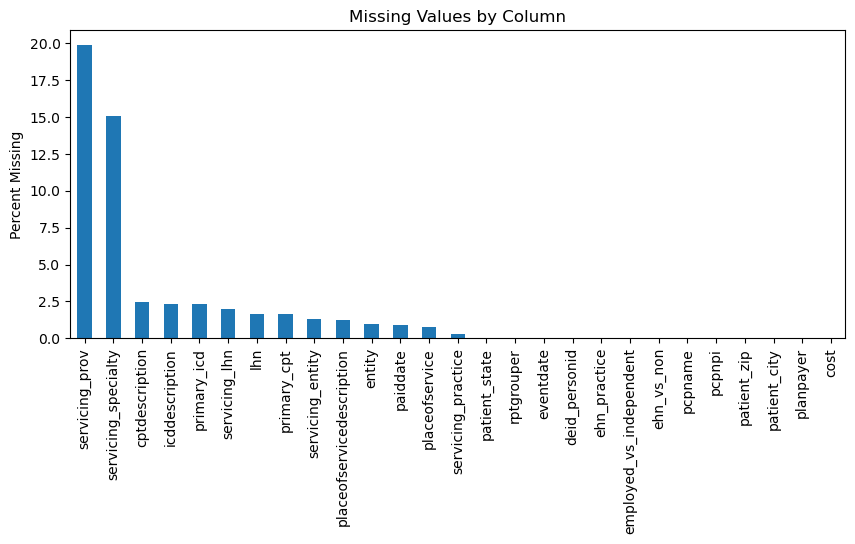

In [20]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100

missing_pct.plot(kind='bar', figsize=(10,4))
plt.ylabel("Percent Missing")
plt.title("Missing Values by Column")
plt.show()

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_zip,5825975.0,6.476963e+06,4.437435e+07,0.0,3.004700e+04,3.013200e+04,3.032700e+04,9.850288e+08
cost,5825975.0,3.575200e+02,2.484616e+03,-41346.0,3.079000e+01,9.819000e+01,2.126300e+02,2.763458e+06
servicing_prov,4666643.0,1.495963e+09,2.938401e+08,795659.0,1.245273e+09,1.487619e+09,1.750757e+09,2.036789e+09


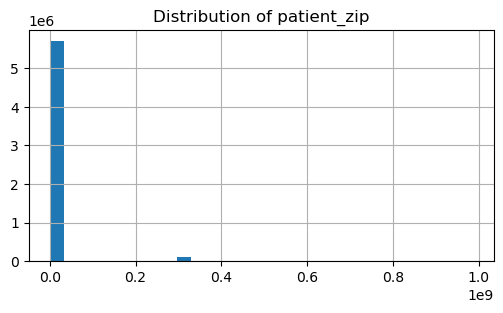

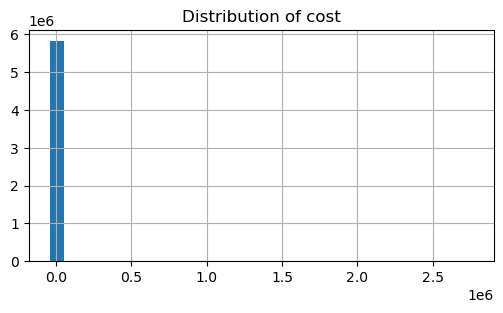

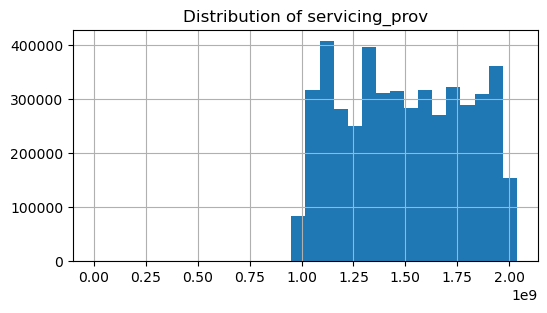

In [22]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

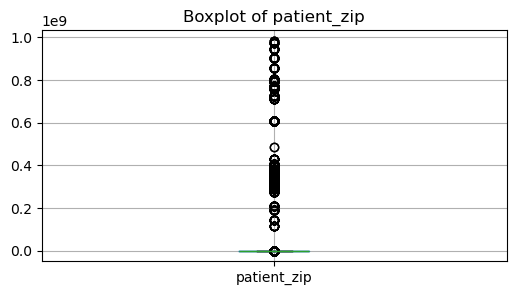

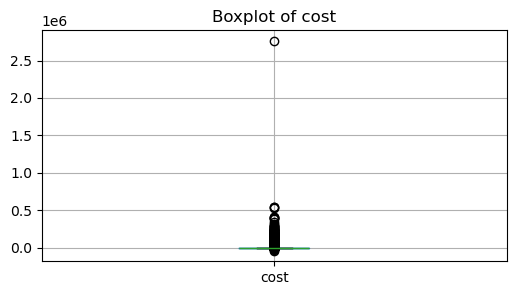

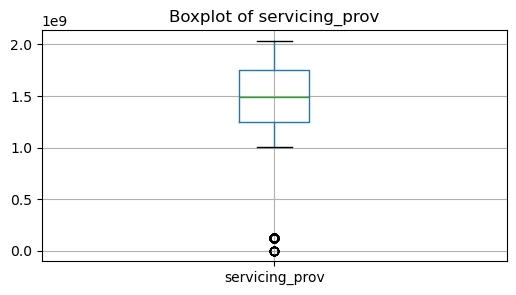

In [23]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [24]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(df[col].value_counts(dropna=False).head(10))
    print("-" * 40)

eventdate
2024-12-16    26895
2024-11-18    26881
2024-12-03    26845
2024-12-17    26695
2024-12-02    26649
2024-12-09    26562
2024-11-12    26530
2024-12-04    26362
2024-10-01    26321
2024-11-19    26295
Name: count, dtype: int64
----------------------------------------
deid_personid
25e19f0fcc3f337fd3a77b048d39c117    899
91f5fbc0c34c719905c918a9aefdfd6c    878
0c8ab9b7ceb01ff1d7ae16e502dc1f20    787
99760e5224cd08bbe34f0facca979340    781
9a899535a8601517aeb4785e7bf8c2a7    758
59c44219e699447dce0139441bd14cf5    716
6299f6d5563979df92f29ffe8cb2c959    692
4286f87a5e4e46a0b367128d87dee7c2    690
b5c3e1cec789f0e04b9078f0ab2df3dc    675
6d04287010b0d3d6ddb2a9504ee3266e    666
Name: count, dtype: int64
----------------------------------------
planpayer
Emory Anthem Commercial                    2088432
Emory MSSP                                  961248
Emory Aetna MAdv                            515667
Emory Aetna Commercial                      462294
Emory Humana MAdv           

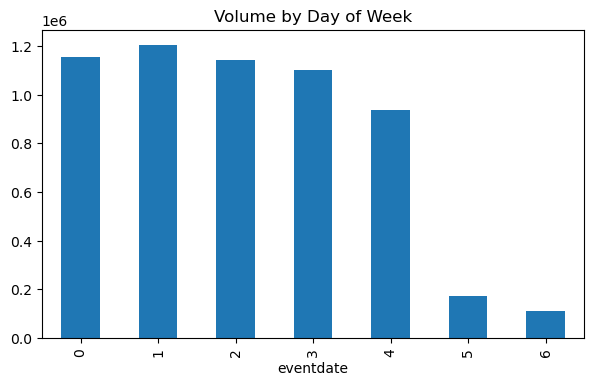

In [26]:
df['eventdate'] = pd.to_datetime(df['eventdate'], errors='coerce')

df['eventdate'].dt.dayofweek.value_counts().sort_index().plot(
    kind='bar', figsize=(7,4)
)
plt.title("Volume by Day of Week")
plt.show()

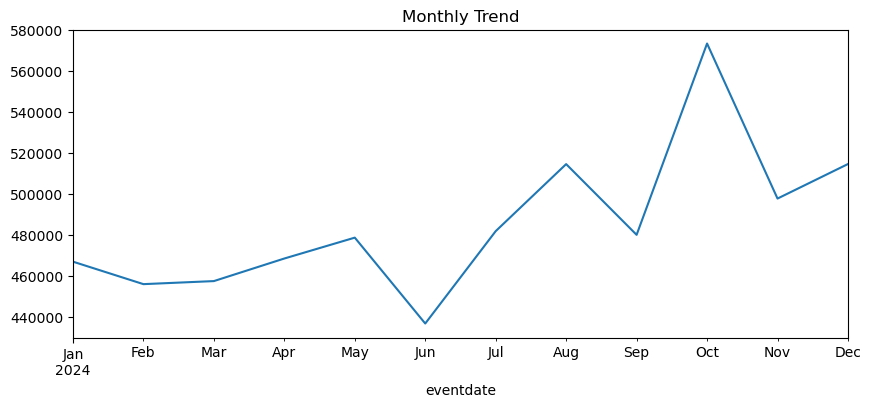

In [28]:
df.groupby(df['eventdate'].dt.to_period('M')).size().plot(figsize=(10,4))
plt.title("Monthly Trend")
plt.show()

In [31]:
df.duplicated().sum()
df[df.duplicated(keep=False)]

,eventdate,deid_personid,planpayer,patient_city,patient_state,patient_zip,pcpnpi,pcpname,ehn_vs_non,employed_vs_independent,...,primary_cpt,cptdescription,primary_icd,icddescription,servicing_prov,servicing_specialty,rptgrouper,servicing_practice,servicing_lhn,servicing_entity
